In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

# Load cleaned data
df = pd.read_csv('../data/cleaned_churn.csv')

# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print("\nChurn rate in train:", round(y_train.mean() * 100, 1), "%")
print("Churn rate in test: ", round(y_test.mean() * 100, 1), "%")

Training set size: (5634, 23)
Test set size:     (1409, 23)

Churn rate in train: 26.5 %
Churn rate in test:  26.5 %


In [2]:
# Calculate class weight for imbalance
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.2f}")

# Build XGBoost model
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Train
model.fit(X_train, y_train)
print("\nModel trained successfully!")

scale_pos_weight: 2.77


c:\Users\nandi\OneDrive\Desktop\customer_churn_prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:35:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model trained successfully!


In [3]:
# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_proba)

print("=== MODEL PERFORMANCE ===")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred,
      target_names=['Stayed', 'Churned']))

=== MODEL PERFORMANCE ===
Accuracy:  75.80%
ROC-AUC:   0.8363

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Stayed       0.91      0.75      0.82      1035
     Churned       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



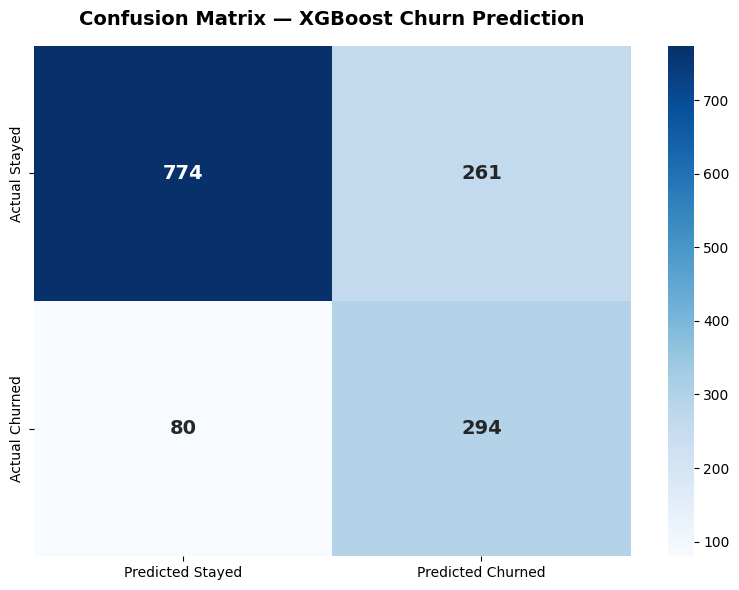


True Negatives  (Correctly predicted Stayed):  774
False Positives (Predicted Churned, Actually Stayed): 261
False Negatives (Predicted Stayed, Actually Churned): 80
True Positives  (Correctly predicted Churned): 294

Out of 374 actual churners, we caught 294 (78.6%)


In [4]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed', 'Predicted Churned'],
            yticklabels=['Actual Stayed', 'Actual Churned'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix — XGBoost Churn Prediction',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../output/06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Explain the numbers
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Correctly predicted Stayed):  {tn}")
print(f"False Positives (Predicted Churned, Actually Stayed): {fp}")
print(f"False Negatives (Predicted Stayed, Actually Churned): {fn}")
print(f"True Positives  (Correctly predicted Churned): {tp}")
print(f"\nOut of {tp+fn} actual churners, we caught {tp} ({tp/(tp+fn)*100:.1f}%)")

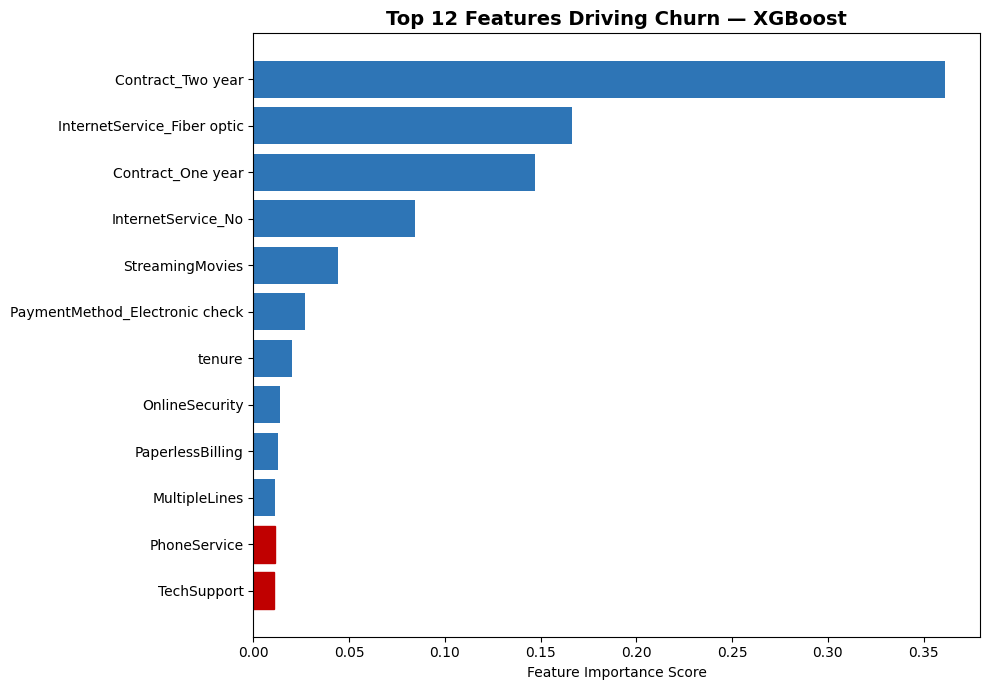


Top 5 churn drivers:
  Contract_Two year: 0.3613
  InternetService_Fiber optic: 0.1666
  Contract_One year: 0.1472
  InternetService_No: 0.0845
  StreamingMovies: 0.0444


In [5]:
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

plt.figure(figsize=(10, 7))
bars = plt.barh(feat_imp['Feature'][::-1],
                feat_imp['Importance'][::-1],
                color='#2E75B6')
bars[0].set_color('#C00000')
bars[1].set_color('#C00000')
plt.title('Top 12 Features Driving Churn — XGBoost',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('../output/07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 churn drivers:")
for i, row in feat_imp.head(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

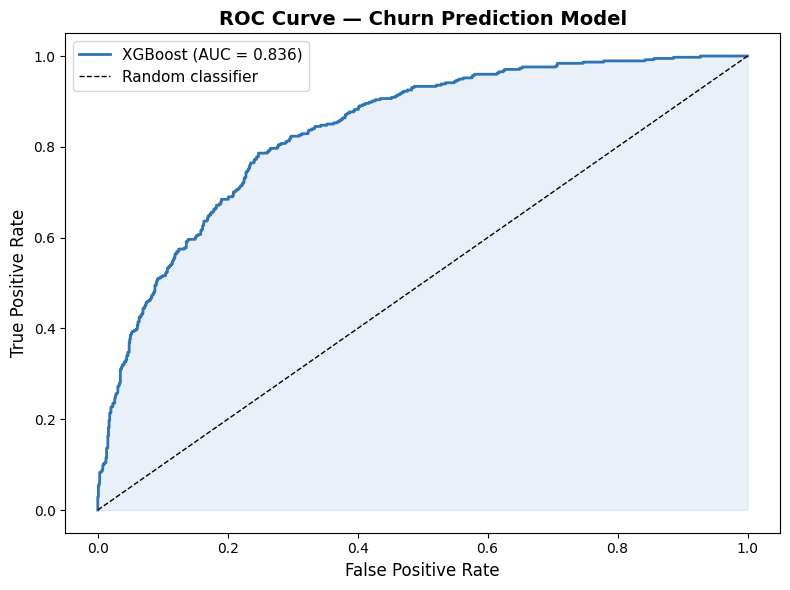

ROC-AUC Score: 0.8363


In [6]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2E75B6', linewidth=2,
         label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2E75B6')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Churn Prediction Model',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../output/08_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC-AUC Score: {roc_auc:.4f}")

In [7]:
joblib.dump(model, '../models/xgboost_churn_model.pkl')
print("Model saved to models/xgboost_churn_model.pkl")

# Verify it loads correctly
loaded_model = joblib.load('../models/xgboost_churn_model.pkl')
test_pred = loaded_model.predict(X_test[:5])
print("Model loads and predicts correctly!")
print("Sample predictions:", test_pred)
print("\nFeature columns saved for Streamlit app:")
print(X_train.columns.tolist())

# Save column names for Streamlit
import json
with open('../models/feature_columns.json', 'w') as f:
    json.dump(X_train.columns.tolist(), f)
print("Feature columns saved to models/feature_columns.json")

Model saved to models/xgboost_churn_model.pkl
Model loads and predicts correctly!
Sample predictions: [0 1 0 1 0]

Feature columns saved for Streamlit app:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
Feature columns saved to models/feature_columns.json
